# Week 5 — calibrated discrete covariate HMMs on DTU CO2 data

**Scope.** One room, 30-minute aggregation, **discrete** models only: a Gaussian and an
autoregressive emission with a covariate-driven (`DynamicTransition`) transition, plus a
**second-order** covariate transition (`DynamicTransitionHigherOrder`) that asks whether the
chain's memory buys anything once the covariates are already in the transition.

**Data.** The cleaning, calibration, covariate construction and splitting all live in
`drivers/clean_dtu_data.py` — run `uv run python -m drivers.clean_dtu_data` once and this
notebook just *loads* `data/<room>/<tag>/{y,X}_{train,val}.csv`. That keeps the
preprocessing in one reviewable place and guarantees every notebook sees the same arrays.

**Calibration** (applied by the driver). The NDIR sensors drift, so the floor of a room's CO2
series sits wherever the sensor's zero happens to be rather than at the ~400 ppm outdoor
background. The driver shifts the whole series by one constant so its minimum is exactly
400 ppm. A pure shift leaves every difference, gap and dynamic untouched — it only makes the
level comparable across rooms and physically interpretable.

**Splits.** The driver cuts the series chronologically into **train → validation → test**, but
this notebook only loads and uses **train + validation**. Models are fitted on train only and
every held-out number below is read off validation; the test block is held back and never touched
here.
Covariates are z-scored with *training* statistics only, so nothing downstream leaks into the
scaling.

**Evaluation.** Rolling **6-hour-ahead** forecasts against a persistence baseline
(RMSE / MAPE / R2) on the validation block, residual diagnostics, and in-sample
LL / AIC / BIC.

## Imports and config

In [1]:
import jax
jax.config.update("jax_enable_x64", True)   # must come before anything touches JAX

from pathlib import Path

import pandas as pd
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

from src.api.v4 import (
    HMM, GaussEmission, AutoregressiveGaussEmission,
    DynamicTransition, DynamicTransitionHigherOrder, ForwardAlgorithm, AIC, BIC,
)
from src.base.utils import transition_matrix_to_logits
from drivers.utils import (
    plot_hmm_diagnostics, load_base_data_path,
    load_train_data, load_val_data,
)

In [ ]:
# --- Which prepared dataset to read ------------------------------------
# Produced by: uv run python -m drivers.clean_dtu_data
# (room, bin, harmonics, weather columns and split fractions are all set there)
ROOM_SLUG = "room_009"
TAG       = "30min"

# --- Which covariates the transition gets ------------------------------
# Entries are either exact column names from `metadata.csv` (e.g. "mean_temp",
# "sin_tod_2") or one of the group shorthands below. Duplicates are dropped and the
# order of `covariate_cols` in the prepared data is preserved, so the selection is
# just a filter over the columns `clean_dtu_data.py` wrote.
#
#   "off_day"  off-day flag (weekend / Danish public holiday)
#   "tod"      time-of-day Fourier terms   (sin_tod_*, cos_tod_*)
#   "week"     weekly Fourier terms        (sin_week_*, cos_week_*)
#   "calendar" off_day + tod + week
#   "weather"  everything that is not a calendar term
#   "all"      every available column
#
# Examples:  ["calendar"] · ["off_day", "tod"] · ["calendar", "mean_temp"] · ["all"]
COVARIATES = [
    
            "mean_temp" 
            ]



COVARIATE_GROUPS = {
    "off_day":  lambda c: c == "off_day",
    "tod":      lambda c: c.startswith(("sin_tod_", "cos_tod_")),
    "week":     lambda c: c.startswith(("sin_week_", "cos_week_")),
    "calendar": lambda c: c == "off_day" or c.startswith(("sin_", "cos_")),
    "weather":  lambda c: not (c == "off_day" or c.startswith(("sin_", "cos_"))),
    "all":      lambda c: True,
}

# --- How many Fourier cycles the calendar terms get ---------------------
# Counts, exactly as `week_5_optimal_parameters.ipynb` samples them: k means
# harmonics 1..k, and 0 drops that block of columns entirely. The prepared data on
# disk is frozen at tod k=1..3 / week k=1, so any other choice is *rebuilt* below
# from the segment's timestamps (the grid is gap-free and regular, so the
# reconstruction is exact) and z-scored on training rows only.
#
# Setting a block to 0 removes its columns, so do not then name them in
# `COVARIATES` — `resolve_covariates` raises rather than silently dropping them.
TOD_HARMONICS  = 1      # daily cycles  -> sin_tod_1..k  / cos_tod_1..k
WEEK_HARMONICS = 0      # weekly cycles -> sin_week_1..k / cos_week_1..k

# --- Model / evaluation config -----------------------------------------
STATES        = 4
AR_LAGS       = 1
ORDER         = 2          # Markov order of the higher-order transition
HORIZON_HOURS = 6


## Load the prepared splits

Everything below comes from `drivers/clean_dtu_data.py`: the longest gap-free 30-min segment of
the room's series, baseline-calibrated, with its covariate matrix z-scored on training rows and
cut chronologically into train / validation / test. Only the train and validation blocks are
read here — the test block stays on disk, untouched, for a single final evaluation elsewhere.

`clean_dtu_data.py` writes *every* covariate it can build; which of them the transition
actually gets is decided here, by `COVARIATES` in the config cell above — a list of exact
column names and/or the group shorthands `off_day` / `tod` / `week` / `calendar` / `weather` /
`all`. Only the selected columns enter `X_train_std` and every fit below; the full matrix is
kept as `X_std_all` / `covariate_cols_all` for the exploration plots, so the correlation
heatmap still shows what you left out.

`metadata.csv` carries the window, the split boundaries, the covariate names and the training
mean/std of every covariate — enough to rebuild the timestamps (the segment is gap-free on a
regular grid) and to un-standardise the covariates for plotting.

The **calendar harmonics are rebuilt here**, not read from the file: `clean_dtu_data.py` froze them
at time-of-day k=1..3 and week k=1, while `week_5_optimal_parameters.ipynb` searches both counts.
`TOD_HARMONICS` / `WEEK_HARMONICS` in the config cell are those same counts (k means harmonics
1..k, 0 drops the block), and the columns are regenerated from the segment's timestamps — the grid
is gap-free and regular, so the reconstruction is exact, and the load cell prints the max
difference against the saved columns to prove it. The off-day flag and the weather block still come
straight off disk. Rebuilt columns are z-scored on the training rows only, as the driver does.

In [3]:
def resolve_covariates(selection, available):
    """Expand `COVARIATES` into column indices into `available`, in the data's own order.

    Every entry must be a group name from `COVARIATE_GROUPS` or an exact column name;
    anything else is a typo and raises rather than silently dropping a covariate.
    """
    chosen = set()
    for entry in selection:
        if entry in COVARIATE_GROUPS:
            matched = [c for c in available if COVARIATE_GROUPS[entry](c)]
            if not matched:
                raise ValueError(f"covariate group {entry!r} matches nothing in {available}")
            chosen.update(matched)
        elif entry in available:
            chosen.add(entry)
        else:
            raise ValueError(
                f"unknown covariate {entry!r}; available columns: {available}\n"
                f"groups: {sorted(COVARIATE_GROUPS)}"
            )
    idx = [i for i, c in enumerate(available) if c in chosen]
    if not idx:
        raise ValueError("COVARIATES selected no columns")
    return idx


def _fourier_columns(harmonics, label, seconds_into, period_seconds):
    """sin/cos pairs for harmonics 1..k of one cycle.

    The same construction as `drivers/clean_dtu_data.build_covariates`, so a column
    rebuilt at the k the driver used reproduces the saved one to float precision --
    which is what the check printed below verifies.
    """
    angle = 2 * np.pi * np.asarray(seconds_into) / period_seconds
    cols, names = [], []
    for k in range(1, harmonics + 1):
        cols += [np.sin(k * angle), np.cos(k * angle)]
        names += [f"sin_{label}_{k}", f"cos_{label}_{k}"]
    return cols, names


def rebuild_calendar_harmonics(dates, X_std, cols, mean, std, train_idx,
                               tod_harmonics, week_harmonics):
    """Swap the saved harmonic columns for `week_harmonics` / `tod_harmonics` of them.

    Returns `(X_std, cols, mean, std)` in the driver's own layout -- off_day, weekly
    terms, daily terms, weather -- so every group shorthand, the un-standardisation and
    the heatmap below keep working unchanged. Only the `sin_*` / `cos_*` columns are
    touched; the off-day flag and the weather block come straight off disk.

    The rebuilt columns are z-scored on the **training rows only**, as the driver
    standardises, so nothing from the validation block leaks into the scaling.
    """
    dt = pd.DatetimeIndex(dates)
    sec_week = dt.dayofweek * 86400 + dt.hour * 3600 + dt.minute * 60 + dt.second
    sec_day = dt.hour * 3600 + dt.minute * 60 + dt.second

    new_cols, new_names = [], []
    c, n = _fourier_columns(week_harmonics, "week", sec_week, 7 * 86400)
    new_cols += c
    new_names += n
    c, n = _fourier_columns(tod_harmonics, "tod", sec_day, 86400)
    new_cols += c
    new_names += n

    X_new = np.column_stack(new_cols) if new_cols else np.empty((len(dt), 0))
    m_new = X_new[:train_idx].mean(axis=0)
    s_new = np.where(X_new[:train_idx].std(axis=0) == 0, 1.0, X_new[:train_idx].std(axis=0))

    X_old = np.asarray(X_std)
    head = [i for i, c in enumerate(cols) if c == "off_day"]
    tail = [i for i, c in enumerate(cols) if not (c == "off_day" or c.startswith(("sin_", "cos_")))]

    X_out = np.concatenate([X_old[:, head], (X_new - m_new) / s_new, X_old[:, tail]], axis=1)
    names_out = [cols[i] for i in head] + new_names + [cols[i] for i in tail]
    mean_out = np.concatenate([mean[head], m_new, mean[tail]])
    std_out = np.concatenate([std[head], s_new, std[tail]])
    return jnp.asarray(X_out), names_out, mean_out, std_out


data_dir = Path(load_base_data_path()) / ROOM_SLUG / TAG
meta     = pd.read_csv(data_dir / "metadata.csv").iloc[0]

room_name          = meta["room_name"]
BIN                = meta["bin"]
BIN_SECONDS        = int(pd.Timedelta(BIN).total_seconds())
BASELINE_PPM       = float(meta["baseline_ppm"])
covariate_cols_all = meta["covariate_cols"].split("|")

ys_train, X_train_all = load_train_data(ROOM_SLUG, TAG)
ys_val,   X_val_all   = load_val_data(ROOM_SLUG, TAG)

# Train and validation as one contiguous series, plus the split boundary as an index into
# it. The forward pass has to filter from the start of the series to have a causal state at
# every validation anchor, which is why they are concatenated at all. The test block is not
# loaded: it is held back for a single final evaluation elsewhere.
ys_agg      = jnp.concatenate([ys_train, ys_val])
X_saved_all = jnp.concatenate([X_train_all, X_val_all])
TRAIN_IDX   = len(ys_train)
dates_agg   = pd.date_range(meta["start"], periods=len(ys_agg), freq=BIN)

# Training mean/std of every saved covariate, used to un-standardise for the plots.
x_mean_saved = np.array([float(meta[f"mean_{c}"]) for c in covariate_cols_all])
x_std_saved  = np.array([float(meta[f"std_{c}"])  for c in covariate_cols_all])
saved_cols   = list(covariate_cols_all)

# The harmonics the driver wrote are frozen at tod k=1..3 / week k=1; rebuild them at
# the configured counts so this notebook can be run at any design the search explored.
X_std_all, covariate_cols_all, x_mean_all, x_std_all = rebuild_calendar_harmonics(
    dates_agg, X_saved_all, saved_cols, x_mean_saved, x_std_saved, TRAIN_IDX,
    TOD_HARMONICS, WEEK_HARMONICS,
)
x_mean_all, x_std_all = jnp.asarray(x_mean_all), jnp.asarray(x_std_all)

# Sanity check on the reconstruction: any harmonic the driver also wrote must come
# back identical (up to float noise), which is what makes the rebuilt columns
# row-aligned with the saved y.
_shared = [c for c in covariate_cols_all if c in saved_cols and c.startswith(("sin_", "cos_"))]
_max_diff = max(
    (float(jnp.max(jnp.abs(X_std_all[:, covariate_cols_all.index(c)]
                           - X_saved_all[:, saved_cols.index(c)]))) for c in _shared),
    default=0.0,
)

# The selection: everything the models touch is the subset, everything the exploration
# plots touch keeps the `_all` suffix so you can see what you did *not* select.
cov_idx        = jnp.asarray(resolve_covariates(COVARIATES, covariate_cols_all))
covariate_cols = [covariate_cols_all[i] for i in cov_idx]
X_std          = X_std_all[:, cov_idx]
# Sliced out of the rebuilt matrix rather than the files, so the configured harmonics
# reach the fits as well as the plots.
X_train_std    = X_std[:TRAIN_IDX]
X_val_std      = X_std[TRAIN_IDX:]

# Un-standardised covariates (X_std * std + mean) — only for the exploration plots below;
# every model is fitted on the standardised matrix.
X_raw_all  = X_std_all * x_std_all + x_mean_all
x_mean, x_std = x_mean_all[cov_idx], x_std_all[cov_idx]
X_raw         = X_raw_all[:, cov_idx]

num_covariates = X_std.shape[1]
# A DynamicTransition has no time-invariant matrix, so the stationary distribution is
# undefined — pass an explicit (uniform) initial distribution instead.
init_dist = jnp.full(STATES, 1.0 / STATES)

dropped = [c for c in covariate_cols_all if c not in covariate_cols]
print(f"{room_name} ({ROOM_SLUG}/{TAG}) — {BIN} bins")
print(f"  window        : {dates_agg[0]} -> {dates_agg[-1]}  ({len(ys_agg)} bins)")
print(f"  baseline shift: {-float(meta['baseline_offset']):+.2f} ppm (min = {BASELINE_PPM:.0f} ppm)")
print(f"  train/val     : {len(ys_train)}/{len(ys_val)} bins (test block not loaded)")
print(f"  boundary      : {dates_agg[TRAIN_IDX]}")
_hk = lambda k: f"k=1..{k}" if k else "none"
print(f"  harmonics     : tod {_hk(TOD_HARMONICS)}, week {_hk(WEEK_HARMONICS)} "
      f"(rebuilt; shared columns match the saved ones to {_max_diff:.1e})")
print(f"  available     : {len(covariate_cols_all)} ({', '.join(covariate_cols_all)})")
print(f"  selected      : {num_covariates} ({', '.join(covariate_cols)})")
print(f"  unused        : {', '.join(dropped) if dropped else '(none)'}")
print(f"  beta budget   : {num_covariates * STATES * (STATES - 1)} parameters "
      f"({num_covariates} covariates x {STATES} x {STATES - 1})")


Room 009 (room_009/30min) — 30min bins
  window        : 2023-11-13 03:30:00 -> 2024-01-22 20:30:00  (3395 bins)
  baseline shift: +33.33 ppm (min = 400 ppm)
  train/val     : 2758/637 bins (test block not loaded)
  boundary      : 2024-01-09 14:30:00
  harmonics     : tod k=1..1, week none (rebuilt; shared columns match the saved ones to 0.0e+00)
  available     : 9 (off_day, sin_tod_1, cos_tod_1, mean_temp, mean_relative_hum, mean_wind_speed, mean_pressure, mean_cloud_cover, mean_radiation)
  selected      : 1 (mean_temp)
  unused        : off_day, sin_tod_1, cos_tod_1, mean_relative_hum, mean_wind_speed, mean_pressure, mean_cloud_cover, mean_radiation
  beta budget   : 12 parameters (1 covariates x 4 x 3)


## Data exploration

Four views before any model is fitted: where the splits fall, what the daily cycle looks like on
work days versus off days, how the covariates move against each other, and what the raw covariate
traces actually look like over a representative fortnight.

### The calibrated series and the split boundaries

A sanity check on the split: each block should cover enough days to contain several full daily
cycles, and the validation block should not look structurally different from training
(a holiday-dominated validation block, say, would make every comparison below a comparison of
periods rather than of models).

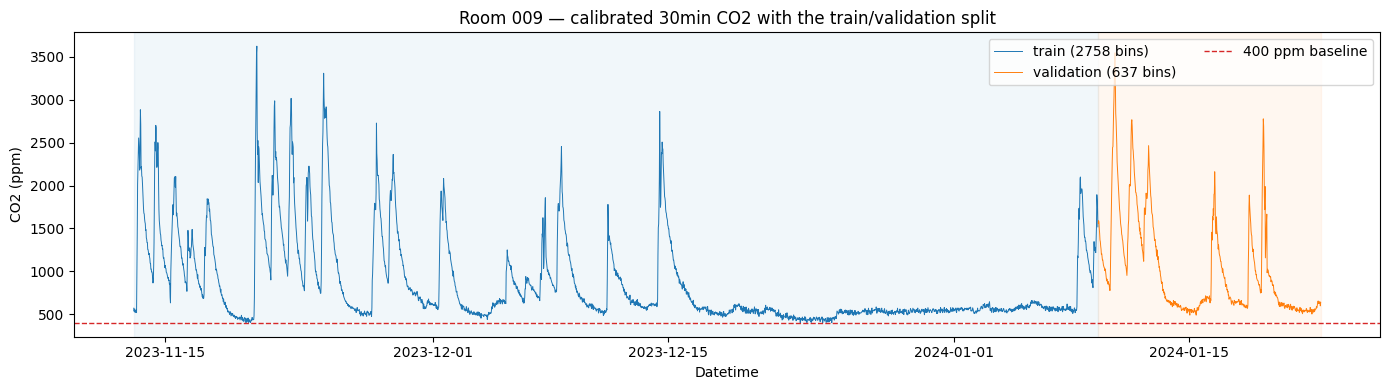

               bins    days      min     mean      max      std
train          2758    57.5    400.0    857.9   3624.3    512.8
validation      637    13.3    490.3   1018.0   3548.0    576.4


In [4]:
fig, ax = plt.subplots(figsize=(14, 4))
blocks = [("train", 0, TRAIN_IDX, "tab:blue"),
          ("validation", TRAIN_IDX, len(ys_agg), "tab:orange")]

for label, lo, hi, colour in blocks:
    ax.plot(dates_agg[lo:hi], np.asarray(ys_agg[lo:hi]), lw=0.7, color=colour,
            label=f"{label} ({hi - lo} bins)")
    ax.axvspan(dates_agg[lo], dates_agg[hi - 1], color=colour, alpha=0.06)

ax.axhline(BASELINE_PPM, color="tab:red", ls="--", lw=1.0, label=f"{BASELINE_PPM:.0f} ppm baseline")
ax.set_title(f"{room_name} — calibrated {BIN} CO2 with the train/validation split")
ax.set_ylabel("CO2 (ppm)")
ax.set_xlabel("Datetime")
ax.legend(loc="upper right", ncol=2)
plt.tight_layout()
plt.show()

print(f"{'':<12}{'bins':>7}{'days':>8}{'min':>9}{'mean':>9}{'max':>9}{'std':>9}")
for label, lo, hi, _ in blocks:
    blk = np.asarray(ys_agg[lo:hi])
    days = (hi - lo) * BIN_SECONDS / 86400
    print(f"{label:<12}{hi - lo:>7}{days:>8.1f}{blk.min():>9.1f}{blk.mean():>9.1f}"
          f"{blk.max():>9.1f}{blk.std():>9.1f}")

### Daily profile, work days versus off days

The `off_day` covariate (weekend or Danish public holiday) is the one flag the transition gets,
so it is worth checking it separates anything. The band is the interquartile range across days,
which is where the *state* structure lives: a wide band in working hours means the room is
sometimes occupied and sometimes not at the same clock time — exactly what a hidden state is
supposed to absorb, and what a purely deterministic time-of-day regression could not.

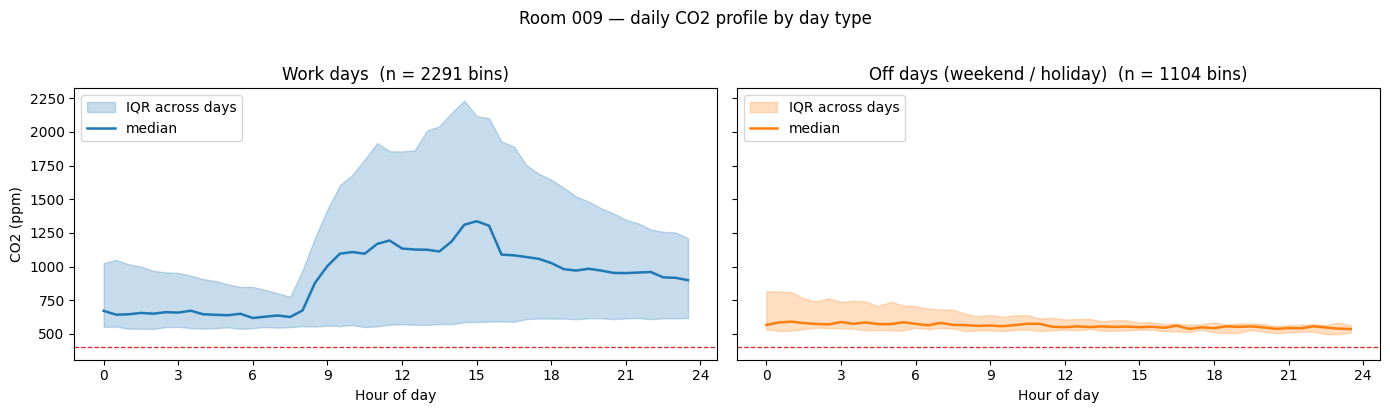

In [5]:
# The off-day flag is read from the *available* columns, so this view works even when
# `off_day` is not one of the selected covariates. If the driver did not build it at all
# (use_off_day=False), fall back to weekend-or-not from the timestamps.
if "off_day" in covariate_cols_all:
    off_day_raw = np.asarray(X_raw_all[:, covariate_cols_all.index("off_day")]) > 0.5
else:
    off_day_raw = (dates_agg.dayofweek >= 5).to_numpy()
    print("no 'off_day' column in the prepared data — using weekends only")
hour_of_day = dates_agg.hour + dates_agg.minute / 60.0

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for ax, (label, mask, colour) in zip(axes, [("Work days", ~off_day_raw, "tab:blue"),
                                            ("Off days (weekend / holiday)", off_day_raw, "tab:orange")]):
    prof = pd.DataFrame({"hour": hour_of_day[mask], "co2": np.asarray(ys_agg)[mask]})
    q = prof.groupby("hour")["co2"].quantile([0.25, 0.5, 0.75]).unstack()
    ax.fill_between(q.index, q[0.25], q[0.75], color=colour, alpha=0.25, label="IQR across days")
    ax.plot(q.index, q[0.5], color=colour, lw=1.8, label="median")
    ax.axhline(BASELINE_PPM, color="tab:red", ls="--", lw=0.9)
    ax.set_title(f"{label}  (n = {mask.sum()} bins)")
    ax.set_xlabel("Hour of day")
    ax.set_xticks(range(0, 25, 3))
    ax.legend(loc="upper left")
axes[0].set_ylabel("CO2 (ppm)")
fig.suptitle(f"{room_name} — daily CO2 profile by day type", y=1.02)
plt.tight_layout()
plt.show()


### How the covariates relate to CO2 and to each other

Pearson correlations on the **training block only**. Two things to read off it: which covariates
carry any marginal signal about the level of CO2 at all, and which pairs are near-collinear.
Collinearity matters here because the transition spends `D * STATES * (STATES - 1)` parameters on
`beta` — two covariates saying the same thing cost the full budget and buy one covariate's worth
of information.

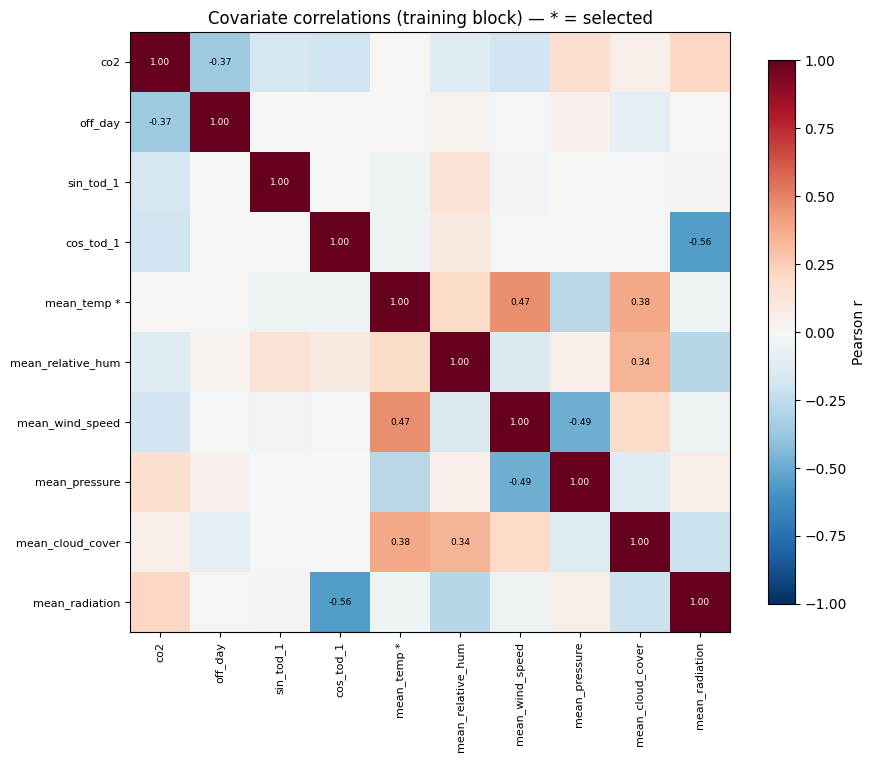

Marginal correlation with CO2 (training block), strongest first:
off_day             -0.367
mean_radiation       0.204
cos_tod_1           -0.198
mean_wind_speed     -0.188
sin_tod_1           -0.165
mean_pressure        0.163
mean_relative_hum   -0.122
mean_cloud_cover     0.050
mean_temp            0.011
Name: co2, dtype: float64


In [6]:
# All *available* covariates, so the heatmap is also the tool for choosing `COVARIATES`;
# the selected ones are marked with a * in the tick labels.
expl = pd.DataFrame(np.asarray(X_raw_all[:TRAIN_IDX]), columns=covariate_cols_all)
expl.insert(0, "co2", np.asarray(ys_train))
corr = expl.corr()
labels = [c if c == "co2" or c not in covariate_cols else f"{c} *" for c in corr.columns]

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)), labels, rotation=90, fontsize=8)
ax.set_yticks(range(len(corr)), labels, fontsize=8)
for i in range(len(corr)):
    for j in range(len(corr)):
        v = corr.values[i, j]
        if abs(v) >= 0.3:
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=6.5,
                    color="white" if abs(v) > 0.6 else "black")
fig.colorbar(im, ax=ax, shrink=0.8, label="Pearson r")
ax.set_title("Covariate correlations (training block) — * = selected")
plt.tight_layout()
plt.show()

print("Marginal correlation with CO2 (training block), strongest first:")
print(corr["co2"].drop("co2").reindex(corr["co2"].drop("co2").abs().sort_values(ascending=False).index).round(3))


### Covariate traces over a representative fortnight

The standardised matrix as the transition actually sees it. The deterministic calendar terms
(off-day flag, weekly and daily harmonics) are exactly periodic by construction; the weather
terms are the only ones carrying genuinely new information per day, and they move on a much
slower scale than the CO2 series does.

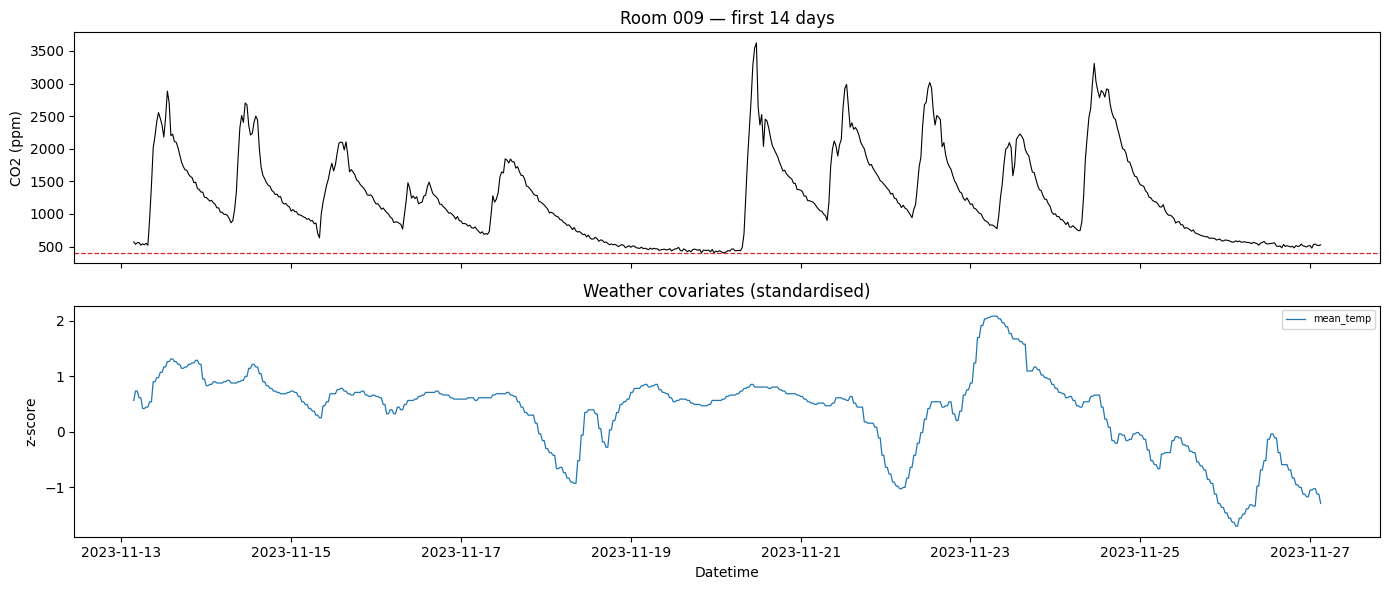

In [7]:
WINDOW_DAYS = 14
w = slice(0, int(WINDOW_DAYS * 86400 / BIN_SECONDS))

# Only the selected columns: this is the matrix the transition actually sees.
calendar_cols = [c for c in covariate_cols if c.startswith(("off_day", "sin_", "cos_"))]
weather_plot  = [c for c in covariate_cols if c not in calendar_cols]

panels = [("Calendar covariates (standardised)", calendar_cols),
          ("Weather covariates (standardised)", weather_plot)]
panels = [(title, cols) for title, cols in panels if cols]

fig, axes = plt.subplots(1 + len(panels), 1, figsize=(14, 3 + 3 * len(panels)), sharex=True)

axes[0].plot(dates_agg[w], np.asarray(ys_agg[w]), lw=0.8, color="black")
axes[0].axhline(BASELINE_PPM, color="tab:red", ls="--", lw=0.9)
axes[0].set_ylabel("CO2 (ppm)")
axes[0].set_title(f"{room_name} — first {WINDOW_DAYS} days")

for ax, (title, cols) in zip(axes[1:], panels):
    for c in cols:
        ax.plot(dates_agg[w], np.asarray(X_std[w, covariate_cols.index(c)]), lw=0.9, label=c)
    ax.set_ylabel("z-score")
    ax.set_title(title)
    ax.legend(loc="upper right", ncol=4, fontsize=7)

axes[-1].set_xlabel("Datetime")
plt.tight_layout()
plt.show()


## Fit the two discrete covariate HMMs

Both use `DynamicTransition` (covariate-driven) with `ts=None`, i.e. unit 30-min steps. Seeds come
from the calibrated training series, so the monotone mean construction
`mu0 + cumsum(exp(log_mu_diff))` starts in the right range. The autoregressive model is
warm-started from the fitted Gaussian model (emission means/sigmas and transition), with the AR
coefficients at zero — at `phi = 0` it *is* the Gaussian model, so the fit can only improve on it.

In [8]:
def state_means(emission, ys):
    """Per-state base means, whichever emission is asked.

    `GaussEmission` exposes them directly as `mu`; the autoregressive emission splits
    them into `mu_vals` (state base) and `mu` (base + AR term on the previous value).
    """
    return getattr(emission, "mu_vals", emission.mu)(0, ys)


mu_seed    = jnp.quantile(ys_train, jnp.linspace(0.05, 0.95, STATES)) 
mu_seed = mu_seed.at[0].set(450)  # avoid degenerate state

sigma_seed = jnp.std(ys_train) * jnp.ones(STATES)
tm_seed    = jnp.full((STATES, STATES), 0.1).at[jnp.diag_indices(STATES)].set(0.7)
beta_init  = jnp.zeros((num_covariates, STATES, STATES - 1))

print("=== Gaussian HMM + covariates (30-min, calibrated) ===")
gauss_cov = HMM(
    emission=GaussEmission.from_params(mu_seed, sigma_seed),
    transition=DynamicTransition(transition_matrix_to_logits(tm_seed), beta_init),
    inital_distribution=init_dist,
)
gauss_cov.fit(ys=ys_train, ts=None, xs=X_train_std, tol=1e-2, frozen={"mu0": False})  # freeze the lowest state mean to avoid degenerate state
print("  log-likelihood:", gauss_cov.log_likelihood())
print("  converged:", gauss_cov.hmm_results.convergence)
print(f"Mu (per state): {np.asarray(gauss_cov.emission.mu(t= 0, ys=0))}")

=== Gaussian HMM + covariates (30-min, calibrated) ===
  log-likelihood: -16341.420745446669
  converged: True
Mu (per state): [ 450.          551.07579713  810.92699971 1640.90030985]


In [9]:
print("=== Autoregressive HMM + covariates (30-min, calibrated) ===")
mu_warm    = state_means(gauss_cov.emission, ys_train)          # fitted state means
sigma_warm = jnp.exp(gauss_cov.emission.log_sigma)

ar_cov = HMM(
    emission=AutoregressiveGaussEmission.from_params(
        mu_warm, sigma_warm, jnp.zeros((AR_LAGS, STATES))
    ),
    transition=DynamicTransition(
        gauss_cov.transition.transition_logits, gauss_cov.transition.beta
    ),
    inital_distribution=init_dist,
)
ar_cov.fit(ys=ys_train, ts=None, xs=X_train_std, tol=1e-2, frozen={"mu0": False})  # freeze the lowest state mean to avoid degenerate state
print("  log-likelihood:", ar_cov.log_likelihood())
print("  converged:", ar_cov.hmm_results.convergence)
print("  phi (per state):", np.asarray(ar_cov.emission.phi()))
print("  AR coefficients (per state):", np.asarray(ar_cov.emission.mu_vals(t=0, ts = 0, ys= 0)))

=== Autoregressive HMM + covariates (30-min, calibrated) ===
  log-likelihood: -13524.204698419966
  converged: True
  phi (per state): [[0.39299285 0.93537522 0.95021415 0.85555872]]
  AR coefficients (per state): [ 450.          558.08702403  609.67739676 2325.00030433]


## Fit a second-order covariate HMM

The chain now runs on **augmented states** `(s_{t-1}, s_t)` — `STATES**ORDER = 16` of them — with
`DynamicTransitionHigherOrder`: covariate-driven like `DynamicTransition`, order-`ORDER` like
`StaticTransitionHigherOrder`. Structurally impossible moves (those whose history does not line up)
are pinned to zero probability, so each augmented state still has only `STATES` real successors.

Two things keep the comparison honest:

- **Tied covariate effects.** `beta` stays `(D, STATES, STATES-1)`, broadcast to every augmented row
  sharing the same current base state. The covariate budget is identical to the first-order model, so
  the only thing added is memory.
- **An exact warm start.** `DynamicTransitionHigherOrder.from_first_order(ar_cov.transition)` lifts
  the fitted first-order transition onto the augmented space, re-referencing the logits so the
  lifted chain reproduces the first-order one at *every* covariate value. The fit therefore starts
  at the first-order optimum.

The emission is autoregressive again, with the `STATES` base means tiled up to the 16 augmented
states (`mu_vals` already does that), so the mean depends only on the current base state.


In [10]:
print("=== Second-order HMM + covariates (30-min, calibrated) ===")
AUG_STATES = STATES ** ORDER

# Augmented state i encodes (s_{t-1}, s_t) as i = s_{t-1} * STATES + s_t, so the current
# base state is i % STATES. `mu_vals` tiles the STATES base means up to len(log_sigma),
# so sigma and phi must be *tiled* (not repeated) to stay aligned with that convention.
mu_so    = state_means(ar_cov.emission, ys_train)[:STATES]         # base means, (STATES,)
sigma_so = jnp.tile(jnp.exp(ar_cov.emission.log_sigma), STATES)    # (AUG_STATES,)
phi_so   = jnp.tile(ar_cov.emission.phi(), (1, STATES))            # (AR_LAGS, AUG_STATES)

so_cov = HMM(
    emission=AutoregressiveGaussEmission.from_params(mu_so, sigma_so, phi_so),
    transition=DynamicTransitionHigherOrder.from_first_order(ar_cov.transition, order=ORDER),
    # No stationary distribution for a covariate-driven chain — uniform over the 16
    # augmented states, whose base-state marginal is the uniform used by the other models.
    inital_distribution=jnp.full(AUG_STATES, 1.0 / AUG_STATES),
)

# Check the lift before spending a fit on it: at the seed this model *is* the fitted
# AR + covariate model, so the two log-likelihoods must agree.
ll_seed = so_cov.log_likelihood(ys=ys_train, xs=X_train_std)
ll_ar   = ar_cov.log_likelihood(ys=ys_train, xs=X_train_std)
print(f"  seed LL {ll_seed:.4f} vs AR+cov LL {ll_ar:.4f}  (difference {ll_seed - ll_ar:.2e})")

so_cov.fit(ys=ys_train, ts=None, xs=X_train_std, tol=1e-2)
print("  log-likelihood:", so_cov.log_likelihood())
print("  converged:", so_cov.hmm_results.convergence)
print("  transition params:", so_cov.transition.transition_logits.size,
      "baseline logits +", so_cov.transition.beta.size, "beta")

# Only the means stay tied to the STATES base states — the fit gets one sigma per
# augmented state, and an almost-never-visited state lets its sigma run toward 0
# (the usual unbounded-likelihood spike). Show occupancy and sigma side by side so
# that is visible rather than buried in the log-likelihood.
utt_so = np.asarray(so_cov.state_results.utt).reshape(len(ys_train), -1)
print("\n  mean filtered occupancy (rows = s_{t-1}, cols = s_t):")
print(np.round(utt_so.mean(axis=0).reshape(-1, STATES), 4))
print("  fitted sigmas (same layout):")
print(np.round(np.asarray(jnp.exp(so_cov.emission.log_sigma)).reshape(-1, STATES), 3))


=== Second-order HMM + covariates (30-min, calibrated) ===
  seed LL -13524.2047 vs AR+cov LL -13524.2047  (difference 0.00e+00)
  log-likelihood: -13441.489953204633
  converged: True
  transition params: 48 baseline logits + 12 beta

  mean filtered occupancy (rows = s_{t-1}, cols = s_t):
[[6.820e-02 3.000e-04 0.000e+00 5.000e-04]
 [4.000e-04 2.635e-01 3.000e-04 1.600e-03]
 [0.000e+00 2.300e-03 5.538e-01 7.500e-03]
 [0.000e+00 0.000e+00 8.700e-03 9.290e-02]]
  fitted sigmas (same layout):
[[1.92870e+01 8.77300e+00 2.95780e+01 1.36000e-01]
 [5.00000e-03 2.07010e+01 3.46800e+00 1.88391e+02]
 [6.23000e+00 2.83490e+01 2.52470e+01 9.70060e+01]
 [1.89550e+01 2.21440e+01 8.71960e+01 2.16915e+02]]


In [11]:
models = {"Gaussian + cov": gauss_cov,
          "Autoregressive + cov": ar_cov,
          "Second-order + cov": so_cov}

for name, m in models.items():
    # Means stay tied to the STATES base states (`mu_vals` tiles them), so one period
    # of them is the whole story. Sigmas are not tied: the second-order model fits one
    # per augmented state, so print the full grid for it.
    mu = np.asarray(state_means(m.emission, ys_train))
    sd = np.asarray(jnp.exp(m.emission.log_sigma))
    print(f"{name}")
    print(f"  state means : {np.round(mu[:STATES], 1)}")
    if sd.size == STATES:
        print(f"  state sigmas: {np.round(sd, 1)}")
    else:
        print(f"  state sigmas (rows = s_t-1, cols = s_t):")
        print(np.round(sd.reshape(-1, STATES), 2))


Gaussian + cov
  state means : [ 450.   551.1  810.9 1640.9]
  state sigmas: [ 23.9  33.9 134.9 483.4]
Autoregressive + cov
  state means : [ 450.   558.1  609.7 2325. ]
  state sigmas: [ 19.   22.1  29.6 209.9]
Second-order + cov
  state means : [ 447.   542.1  579.  2321.8]
  state sigmas (rows = s_t-1, cols = s_t):
[[1.9290e+01 8.7700e+00 2.9580e+01 1.4000e-01]
 [1.0000e-02 2.0700e+01 3.4700e+00 1.8839e+02]
 [6.2300e+00 2.8350e+01 2.5250e+01 9.7010e+01]
 [1.8960e+01 2.2140e+01 8.7200e+01 2.1692e+02]]


## In-sample fit criteria

In [12]:
rows = []
for name, m in models.items():
    res = m.hmm_results
    rows.append({
        "Model": name,
        "LL": res.log_likelihood,
        "#Params": res.num_params,
        "AIC": AIC(res),
        "BIC": BIC(res, len(ys_train)),
        "Converged": res.convergence,
    })

fit_table = pd.DataFrame(rows)
fit_table["dAIC"] = fit_table["AIC"] - fit_table["AIC"].min()
fit_table["dBIC"] = fit_table["BIC"] - fit_table["BIC"].min()
fit_table = fit_table[["Model", "LL", "#Params", "AIC", "dAIC", "BIC", "dBIC", "Converged"]]
fit_table.round(2)

,Model,LL,#Params,AIC,dAIC,BIC,dBIC,Converged
0,Gaussian + cov,-16341.42,32,32746.84,5671.86,32936.35,5602.74,True
1,Autoregressive + cov,-13524.20,36,27120.41,45.43,27333.61,0.00,True
2,Second-order + cov,-13441.49,96,27074.98,0.00,27643.52,309.91,True


## Residual diagnostics

`plot_hmm_diagnostics` (from `drivers/utils.py`) shows the log-likelihood per solver iteration,
a normal Q-Q plot of the forecast pseudo-residuals, and their ACF. Under a well-specified model
the pseudo-residuals are i.i.d. standard normal, so the Q-Q line should be straight and the ACF
flat.

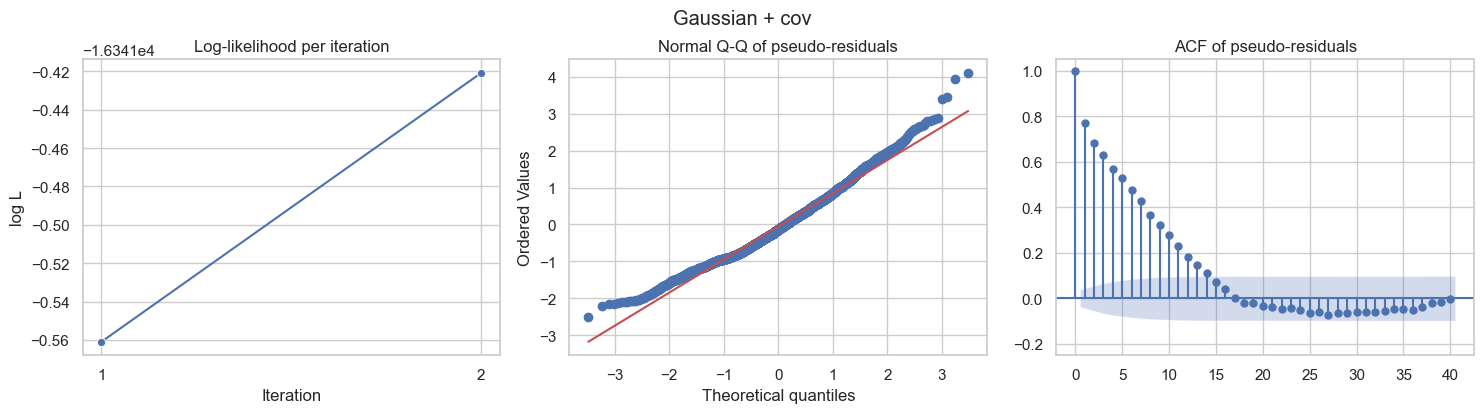

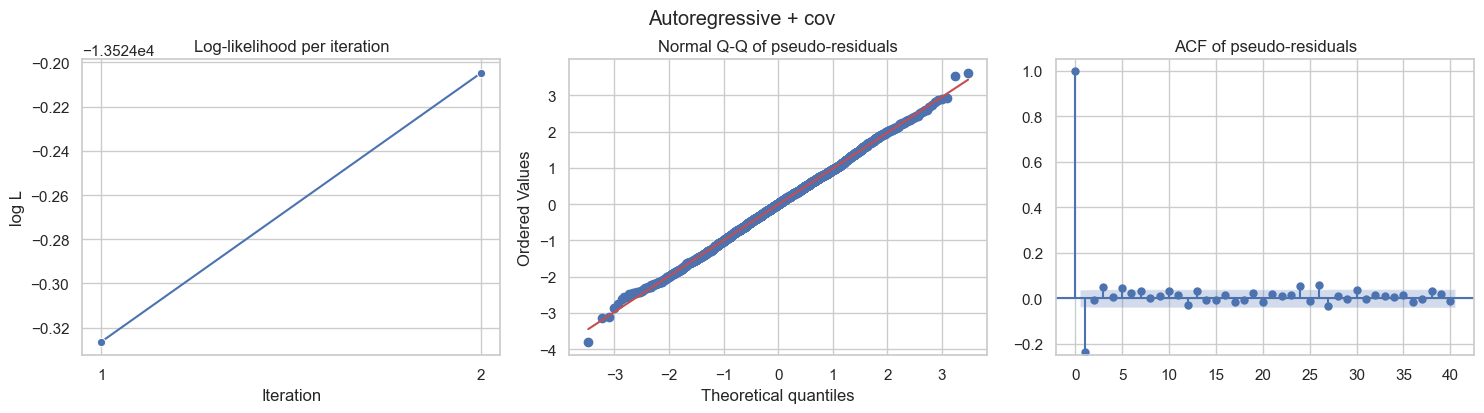

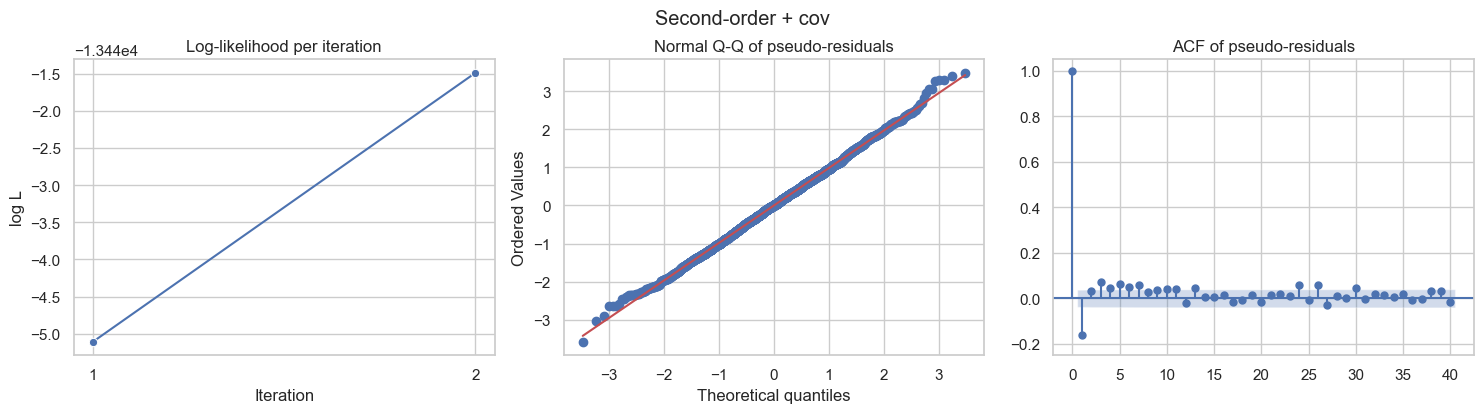

In [13]:
for name, m in models.items():
    fig = plot_hmm_diagnostics(m)
    fig.suptitle(name, y=1.03)
    plt.show()

### Decoded states over the training window

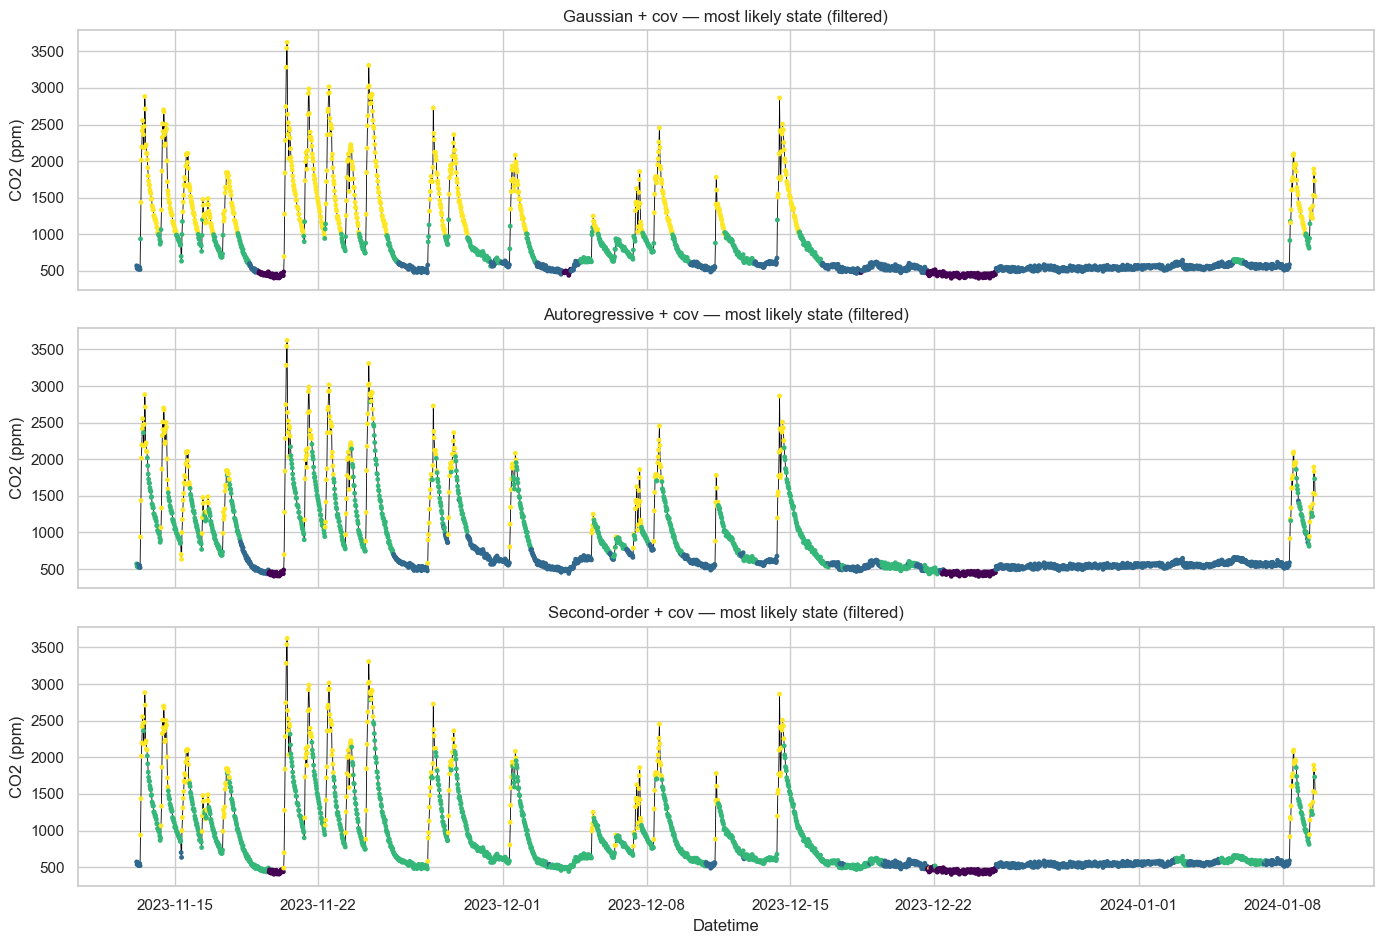

In [14]:
fig, axes = plt.subplots(len(models), 1, figsize=(14, 3.2 * len(models)), sharex=True)
for ax, (name, m) in zip(np.atleast_1d(axes), models.items()):
    utt = np.asarray(m.state_results.utt).reshape(len(ys_train), -1)
    # Augmented index i has current base state i % STATES, so the second-order
    # model shares one colour scale with the first-order ones.
    decoded = utt.argmax(axis=1) % STATES
    ax.plot(dates_agg[:TRAIN_IDX], np.asarray(ys_train), color="black", lw=0.6, zorder=1)
    ax.scatter(dates_agg[:TRAIN_IDX], np.asarray(ys_train), c=decoded, cmap="viridis",
               s=6, zorder=2)
    ax.set_title(f"{name} — most likely state (filtered)")
    ax.set_ylabel("CO2 (ppm)")
np.atleast_1d(axes)[-1].set_xlabel("Datetime")
plt.tight_layout()
plt.show()

## Predictive metrics

In [15]:
def rmse(y_true, y_pred):
    return float(jnp.sqrt(jnp.mean((y_true - y_pred) ** 2)))

def r2_score(y_true, y_pred):
    ss_res = jnp.sum((y_true - y_pred) ** 2)
    ss_tot = jnp.sum((y_true - jnp.mean(y_true)) ** 2)
    return float(1 - ss_res / ss_tot)

def mape(y_true, y_pred):
    return float(jnp.mean(jnp.abs((y_true - y_pred) / y_true)) * 100)

## Rolling 6-hour-ahead forecast

At **every** anchor in an evaluation block we take the causal filtered state and propagate it `K`
steps forward through the model's own transition matrices, then compare the emission mean to the
CO2 actually realised that far ahead. Filtering is causal, so one forward pass over the whole
series leaks nothing — the covariates at future steps are exogenous time/weather features, not
the target.

- `K = 6 h / 30 min = 12` steps.
- **Autoregressive:** the emission mean depends on the previous observation, unknown in the
  future, so the model's own running prediction is fed back in as the lag (plug-in multi-step
  forecast).
- Anchors run over `[start, end - K)` so that every target lands inside the block being scored —
  here the **validation** block only, so no target is ever read from the training block. The test
  block is not loaded at all, so nothing below can see it.

In [16]:
def rolling_discrete(model, ys, xs_std, dates, start, end, K, is_ar=False):
    """Fixed K-step-ahead forecast anchored at every observation of the block [start, end).

    Anchors stop at `end - K` so every target y[anchor + K] falls inside the block, which is
    what keeps the scores clear of the training block.
    """
    ys = jnp.asarray(ys)
    T = len(ys)
    out = ForwardAlgorithm().run(model.params, model.u_pre, ys=ys, ts=None, xs=xs_std)
    utt = out.utt.reshape(T, -1)                                              # (T, S)
    # transition_matrices(indices, ts, ys, xs): `ts` is ignored by a discrete
    # transition, so unit waiting times are fine here.
    Gammas = model.transition.transition_matrices(
        jnp.arange(T), jnp.ones(T), ys, xs_std
    )                                                                         # (T, S, S)

    anchors = jnp.arange(start, end - K)
    u = utt[anchors]
    if not is_ar:
        mu = model.emission.mu(0, ys, xs_std)                                 # (S,)
        for m in range(1, K + 1):
            u = jnp.einsum("ai,aij->aj", u, Gammas[anchors + m])
        y_pred = u @ mu
    else:
        base = model.emission.mu_vals(0, ys, xs_std)                          # (S,) state base means
        phi  = model.emission.phi()[0]                                        # (S,) lag-1 coeff/state
        y_lag = ys[anchors]                                                   # last observed value
        y_pred = None
        for m in range(1, K + 1):
            u = jnp.einsum("ai,aij->aj", u, Gammas[anchors + m])
            mu_state = base[None, :] + phi[None, :] * (y_lag[:, None] - base[None, :])  # (A, S)
            y_pred = jnp.sum(u * mu_state, axis=1)                            # state-weighted mean
            y_lag = y_pred                                                    # plug-in next lag
    y_true = ys[anchors + K]
    tgt_dates = dates[np.asarray(anchors) + K]
    return tgt_dates, np.asarray(y_true), np.asarray(y_pred)


def rolling_baseline(ys, dates, start, end, K):
    """Persistence: predict y[anchor+K] as the current value y[anchor]."""
    ys = jnp.asarray(ys)
    anchors = jnp.arange(start, end - K)
    return (dates[np.asarray(anchors) + K],
            np.asarray(ys[anchors + K]),      # realised 6 h later
            np.asarray(ys[anchors]))          # current observation


def forecast_block(start, end, K):
    """All four forecasters scored over one contiguous block of the series (validation)."""
    return {
        "Persistence baseline": rolling_baseline(ys_agg, dates_agg, start, end, K),
        "Gaussian + cov":       rolling_discrete(gauss_cov, ys_agg, X_std, dates_agg, start, end, K, is_ar=False),
        "Autoregressive + cov": rolling_discrete(ar_cov,    ys_agg, X_std, dates_agg, start, end, K, is_ar=True),
        "Second-order + cov":   rolling_discrete(so_cov,    ys_agg, X_std, dates_agg, start, end, K, is_ar=True),
    }

In [17]:
K = int(round(HORIZON_HOURS * 3600 / BIN_SECONDS))     # 12 steps at 30 min
print(f"Horizon: {HORIZON_HOURS} h = {K} steps")

block_results = {"validation": forecast_block(TRAIN_IDX, len(ys_agg), K)}

pred_table = pd.DataFrame([
    {"Block": block,
     "Model": name,
     "RMSE": rmse(jnp.asarray(yt), jnp.asarray(yp)),
     "MAPE%": mape(jnp.asarray(yt), jnp.asarray(yp)),
     "R2": r2_score(jnp.asarray(yt), jnp.asarray(yp)),
     "n": len(yt)}
    for block, res in block_results.items()
    for name, (td, yt, yp) in res.items()
])
pred_table = pred_table.pivot(index="Model", columns="Block", values=["RMSE", "MAPE%", "R2"])
pred_table.round(3)

Horizon: 6 h = 12 steps


,RMSE,MAPE%,R2
Block,validation,validation,validation
Model,,,
Autoregressive + cov,459.054,21.479,0.372
Gaussian + cov,484.851,28.594,0.300
Persistence baseline,524.299,22.900,0.181
Second-order + cov,450.370,23.005,0.396


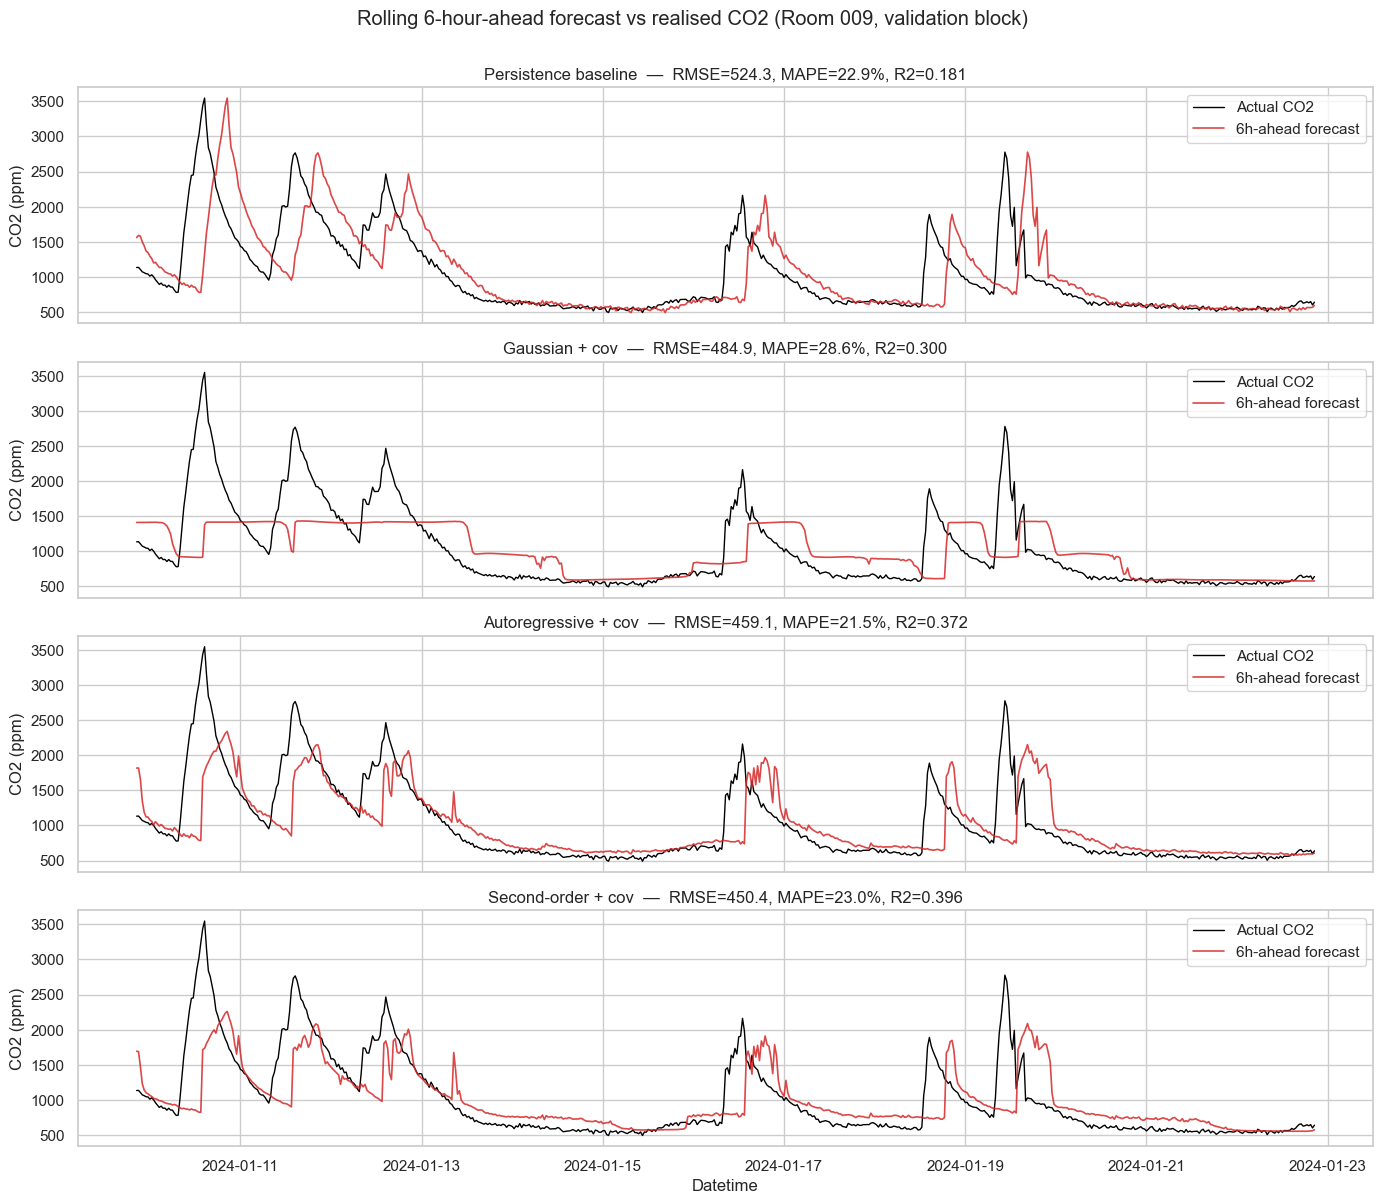

In [18]:
for block, results in block_results.items():
    fig, axes = plt.subplots(len(results), 1, figsize=(14, 3 * len(results)), sharex=True)
    axes = np.atleast_1d(axes)
    for ax, (name, (td, yt, yp)) in zip(axes, results.items()):
        yt_j, yp_j = jnp.asarray(yt), jnp.asarray(yp)
        ax.plot(td, yt, color="black", lw=1.0, label="Actual CO2")
        ax.plot(td, yp, color="tab:red", lw=1.2, alpha=0.85, label=f"{HORIZON_HOURS}h-ahead forecast")
        ax.set_title(f"{name}  —  RMSE={rmse(yt_j, yp_j):.1f}, "
                     f"MAPE={mape(yt_j, yp_j):.1f}%, R2={r2_score(yt_j, yp_j):.3f}")
        ax.set_ylabel("CO2 (ppm)")
        ax.legend(loc="upper right")
    axes[-1].set_xlabel("Datetime")
    fig.suptitle(f"Rolling {HORIZON_HOURS}-hour-ahead forecast vs realised CO2 "
                 f"({room_name}, {block} block)", y=1.002)
    plt.tight_layout()
    plt.show()

### Forecast errors over the held-out blocks

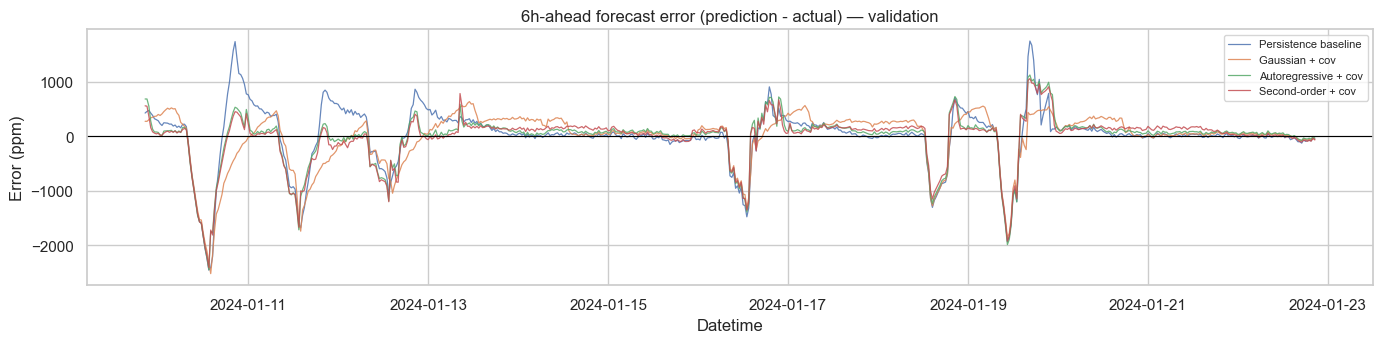

In [19]:
fig, axes = plt.subplots(len(block_results), 1, figsize=(14, 3.6 * len(block_results)))
for ax, (block, results) in zip(np.atleast_1d(axes), block_results.items()):
    for name, (td, yt, yp) in results.items():
        ax.plot(td, np.asarray(yp) - np.asarray(yt), lw=0.9, alpha=0.85, label=name)
    ax.axhline(0.0, color="black", lw=0.8)
    ax.set_title(f"{HORIZON_HOURS}h-ahead forecast error (prediction - actual) — {block}")
    ax.set_ylabel("Error (ppm)")
    ax.legend(loc="upper right", fontsize=8)
np.atleast_1d(axes)[-1].set_xlabel("Datetime")
plt.tight_layout()
plt.show()

In [20]:
t = gauss_cov.transition.transition_matrix(xs=jnp.asarray(X_std[0, :]))

In [21]:
def matrix_power(A, k): 
    for i in range(k - 1):
        A = (A @ A)/A.sum(axis=1, keepdims=True)  # normalise rows to sum to 1 
    return A

In [22]:
t

Array([[9.85876326e-01, 9.31303797e-03, 4.11368416e-05, 4.76949920e-03],
       [2.70440651e-03, 9.93131159e-01, 1.84053562e-03, 2.32389922e-03],
       [1.36474017e-05, 1.02135429e-02, 9.63259993e-01, 2.65128168e-02],
       [1.09850319e-05, 1.10341648e-05, 2.61920278e-02, 9.73785953e-01]],      dtype=float64)

In [23]:
t.sum(axis=1)  # sanity check: each row sums to 1.0

Array([1., 1., 1., 1.], dtype=float64)

In [24]:
matrix_power(t, 48) # sanity check: each row sums to 1.0

Array([[0.08314808, 0.4320578 , 0.2144596 , 0.27033451],
       [0.08314808, 0.4320578 , 0.2144596 , 0.27033451],
       [0.08314808, 0.4320578 , 0.2144596 , 0.27033451],
       [0.08314808, 0.4320578 , 0.2144596 , 0.27033451]], dtype=float64)